# Supervised Learning — Improved Methods (Test / Experimental)

**Moody's Ratings Capstone — NB5 Experimental Branch**

This notebook addresses the main methodological weaknesses of `5_ML_FINAL.ipynb`:
1. **Temporal hold-out** — train 1995–2014, test 2015–2019 (no in-sample flattery)
2. **ΔECI target** — predicts year-on-year change rather than level (removes persistence bias)
3. **Enhanced features** — 5-year rolling volatility controls + resource concentration (HHI)
4. **XGBoost** — alongside regularised linear models and Random Forest
5. **SHAP values** — model-agnostic importance replacing coefficient charts
6. **Prediction intervals** — quantile regression for 80% coverage bands

Cluster integration is deferred to a future version.

## 0. Setup and Data Loading

Same data source and 54-country sample as `5_ML_FINAL`. All improvements are methodological, not a sample change.

In [21]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — run: pip install xgboost")

try:
    import shap
    HAS_SHAP = True
    print("SHAP available")
except ImportError:
    HAS_SHAP = False
    print("SHAP not installed — run: pip install shap")

# ── Output directories ────────────────────────────────────────────────────────
OUT = os.path.join('Graphics', 'NB5_TEST')
os.makedirs(OUT, exist_ok=True)

# ── Load master panel ─────────────────────────────────────────────────────────
master = pd.read_csv('../FINAL CODE RECAP/intermediary/Master.csv')
print(f"Master: {len(master)} obs, {master['Country Code'].nunique()} countries")

# ── 54-country sample (same as NB4 / 5_ML_FINAL) ─────────────────────────────
include_list = [
    'AGO', 'ARE', 'AZE', 'BFA', 'BHR', 'BOL', 'CHL', 'CIV', 'CMR',
    'COD', 'COG', 'DZA', 'ECU', 'EGY', 'ETH', 'GAB', 'GHA', 'GIN',
    'GNQ', 'IDN', 'IRN', 'IRQ', 'KAZ', 'KEN', 'KWT', 'LAO', 'LBR',
    'LBY', 'MDG', 'MLI', 'MMR', 'MNG', 'MOZ', 'MWI', 'MYS', 'NER',
    'NGA', 'OMN', 'PNG', 'QAT', 'RUS', 'RWA', 'SAU', 'TCD', 'TGO',
    'TTO', 'TZA', 'UGA', 'UZB', 'VEN', 'VNM', 'YEM', 'ZMB', 'ZWE',
]

df = master[
    (master['Year'] >= 1995) &
    (master['Year'] <= 2019) &
    (master['Country Code'].isin(include_list))
].copy()
df = df.sort_values(['Country Code', 'Year']).reset_index(drop=True)
print(f"After sample filter: {df['Country Code'].nunique()} countries, {len(df)} obs")

XGBoost available
SHAP available
Master: 3275 obs, 131 countries
After sample filter: 54 countries, 1350 obs


## 1. Feature Engineering

Three additions over `5_ML_FINAL`:
- **Rolling 5-year mean** of inflation and real interest rate — captures medium-term macro environment rather than noisy annual snapshots.
- **Resource HHI** — Herfindahl-Hirschman index across oil, gas, and mineral rents. Measures whether a country's resource base is concentrated in one commodity or diversified. HHI = 1 means fully concentrated, approaching 0 means balanced.
- **ΔECI target** (alongside level) — predicts ECI change year-on-year. This is the main methodological improvement: removes the persistence bias from L1_ECI dominating the prediction.

In [22]:
# ── Rolling macro controls (5-year backward-looking rolling mean) ──────────────
df['Inflation_roll5'] = (
    df.groupby('Country Code')['Inflation, consumer prices (annual %)'].
    transform(lambda x: x.rolling(5, min_periods=3).mean())
)
df['RealRate_roll5'] = (
    df.groupby('Country Code')['Real interest rate (%)'].
    transform(lambda x: x.rolling(5, min_periods=3).mean())
)

# ── Resource concentration (HHI) ──────────────────────────────────────────────
# Shares of total NR rents from oil, gas, mineral. Squared and summed.
rents_cols = [
    'Oil rents (% of GDP)',
    'Natural gas rents (% of GDP)',
    'Mineral rents (% of GDP)',
]
total_rents = df['Total natural resources rents (% of GDP)'].replace(0, np.nan)
df['Resource_HHI'] = sum(
    (df[col] / total_rents) ** 2 for col in rents_cols
).fillna(0.33)  # fill missing with equal-split assumption

# ── ECI targets ───────────────────────────────────────────────────────────────
df['L1_ECI']    = df.groupby('Country Code')['Economic Complexity Index'].shift(1)
df['ECI_delta'] = df['Economic Complexity Index'] - df['L1_ECI']  # ΔECI

# ── Interaction terms ─────────────────────────────────────────────────────────
df['HCI_x_ProductionValue']       = df['Human capital index'] * df['Total_Production_Value']
df['RuleOfLaw_x_ProductionValue'] = df['Rule of law index']   * df['Total_Production_Value']

df = df.dropna(subset=['L1_ECI', 'Economic Complexity Index', 'ECI_delta'])

# ── Feature lists ─────────────────────────────────────────────────────────────
base_features = [
    'Total_Production_Value',
    'Human capital index',
    'Rule of law index',
    'Political stability — estimate',
    'Trade (% of GDP)',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Share of investment in GDP',
    'Domestic credit to private sector (% of GDP)',
    'Landlocked',
    'Urban population (% of total population)',
    'Government revenue',
    'Capital depreciation rate',
    'Use of IMF credit (DOD, current US$)',
    'Real interest rate (%)',
    'Inflation, consumer prices (annual %)',
    'Access to electricity (% of population)',
    'Adjusted savings: gross savings (% of GNI)',
    'L1_ECI'
]
new_features = [
    'Inflation_roll5',
    'RealRate_roll5',
    'Resource_HHI',
]
interaction_features = [
    'HCI_x_ProductionValue',
    'RuleOfLaw_x_ProductionValue',
]
all_features = base_features + new_features + interaction_features

print(f"Total features: {len(all_features)} ({len(base_features)} base + {len(new_features)} new + {len(interaction_features)} interactions)")

# ── Log transforms ────────────────────────────────────────────────────────────
# ECI level (shift-adjusted log)
#eci_min = df['Economic Complexity Index'].min()
#df['log_ECI'] = np.log(df['Economic Complexity Index'] - eci_min + 1)

#l1_min = df['L1_ECI'].min()
#df['log_L1_ECI'] = np.log(df['L1_ECI'] - l1_min + 1)
#df['L1_ECI'] = df['log_L1_ECI']  # replace in-place for feature list

log_features = [
    'Human capital index',
    'Total_Production_Value',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Government revenue',
    'Use of IMF credit (DOD, current US$)',
]
df[log_features] = np.log1p(df[log_features])
df[log_features] = df[log_features].replace([np.inf, -np.inf], np.nan)

df = df.dropna(subset=all_features)
print(f"After transforms + dropna: {len(df)} obs, {df['Country Code'].nunique()} countries")

Total features: 23 (18 base + 3 new + 2 interactions)
After transforms + dropna: 1199 obs, 53 countries


## 2. Temporal Train / Test Split

Train: 1995–2014 (≈ 20 years). Test: 2015–2019 (5 years). This is a strict temporal hold-out — no test data ever seen during fitting or hyperparameter selection. The scaler is fit on train only.

In [23]:
TRAIN_END = 2014
TEST_START = 2015

train_df = df[df['Year'] <= TRAIN_END].copy()
test_df  = df[df['Year'] >= TEST_START].copy()

print(f"Train: {len(train_df)} obs | {train_df['Year'].min()}–{train_df['Year'].max()} | {train_df['Country Code'].nunique()} countries")
print(f"Test : {len(test_df)} obs  | {test_df['Year'].min()}–{test_df['Year'].max()}  | {test_df['Country Code'].nunique()} countries")

# ── Two targets ───────────────────────────────────────────────────────────────
# (A) ECI level — comparable to 5_ML_FINAL
y_train_level = train_df['Economic Complexity Index'].values
y_test_level  = test_df['Economic Complexity Index'].values

# (B) ΔECI — removes persistence bias
y_train_delta = train_df['ECI_delta'].values
y_test_delta  = test_df['ECI_delta'].values

# ── Scale (fit on train only) ─────────────────────────────────────────────────
X_train_raw = train_df[all_features].values
X_test_raw  = test_df[all_features].values

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)  # transform only, do NOT refit

tscv = TimeSeriesSplit(n_splits=5, gap=1)

print("\nScaler fit on train only. Test set transformed with train statistics.")

Train: 934 obs | 1997–2014 | 53 countries
Test : 265 obs  | 2015–2019  | 53 countries

Scaler fit on train only. Test set transformed with train statistics.


## 3. Model Training

Five models trained on the train set only. XGBoost uses early stopping on a 20% validation slice carved from the end of train (to avoid leaking test info). Linear models use `TimeSeriesSplit` CV for alpha selection. Both targets (level and ΔECI) are fitted.

In [24]:
def fit_all_models(X_tr, y_tr, tscv, label=''):
    """Fit LASSO, Ridge, Elastic Net, RF, optionally XGBoost. Returns dict."""
    print(f"\nFitting models for target: {label}")

    lasso   = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_tr, y_tr)
    ridge   = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=tscv).fit(X_tr, y_tr)
    elastic = ElasticNetCV(l1_ratio=[0.5], cv=tscv, random_state=42, max_iter=10000).fit(X_tr, y_tr)
    rf      = RandomForestRegressor(
        n_estimators=200, max_depth=4, min_samples_leaf=10,
        random_state=42, n_jobs=-1, oob_score=True
    ).fit(X_tr, y_tr)

    out = {'LASSO': lasso, 'Ridge': ridge, 'Elastic Net': elastic, 'Random Forest': rf}

    if HAS_XGB:
        # Carve last 15% of train as internal val for early stopping
        n_val = max(10, int(0.15 * len(X_tr)))
        X_val_xgb, y_val_xgb = X_tr[-n_val:], y_tr[-n_val:]
        X_fit_xgb, y_fit_xgb = X_tr[:-n_val], y_tr[:-n_val]

        xgb_model = xgb.XGBRegressor(
            n_estimators=500, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
            random_state=42, n_jobs=-1,
            early_stopping_rounds=30, eval_metric='rmse',
        )
        xgb_model.fit(
            X_fit_xgb, y_fit_xgb,
            eval_set=[(X_val_xgb, y_val_xgb)],
            verbose=False,
        )
        out['XGBoost'] = xgb_model
        print(f"  XGBoost best iteration: {xgb_model.best_iteration}")

    print(f"  LASSO α={lasso.alpha_:.4f}  Ridge α={ridge.alpha_:.4f}  EN α={elastic.alpha_:.4f}  RF OOB={rf.oob_score_:.3f}")
    return out

models_level = fit_all_models(X_train, y_train_level, tscv, label='ECI')
models_delta = fit_all_models(X_train, y_train_delta, tscv, label='ΔECI')


Fitting models for target: ECI
  XGBoost best iteration: 36
  LASSO α=0.0221  Ridge α=11.4976  EN α=0.0334  RF OOB=0.763

Fitting models for target: ΔECI
  XGBoost best iteration: 4
  LASSO α=0.0157  Ridge α=215.4435  EN α=0.0274  RF OOB=0.088


## 4. Out-of-Sample Evaluation

Train and test metrics are reported side-by-side. The gap between train R² and test R² is the key diagnostic — large gaps indicate overfitting. Test RMSE on ΔECI is a more honest signal of predictive power than level R².

In [25]:
def eval_models(models, X_tr, y_tr, X_te, y_te):
    rows = []
    for name, model in models.items():
        pred_tr = model.predict(X_tr)
        pred_te = model.predict(X_te)
        rows.append({
            'Model':       name,
            'Train R²':   round(r2_score(y_tr, pred_tr), 4),
            'Test R²':    round(r2_score(y_te, pred_te), 4),
            'Train RMSE': round(np.sqrt(mean_squared_error(y_tr, pred_tr)), 4),
            'Test RMSE':  round(np.sqrt(mean_squared_error(y_te, pred_te)), 4),
            'Train MAE':  round(mean_absolute_error(y_tr, pred_tr), 4),
            'Test MAE':   round(mean_absolute_error(y_te, pred_te), 4),
            'Overfit Gap': round(r2_score(y_tr, pred_tr) - r2_score(y_te, pred_te), 4),
        })
    return pd.DataFrame(rows).sort_values('Test R²', ascending=False).reset_index(drop=True)

perf_level = eval_models(models_level, X_train, y_train_level, X_test, y_test_level)
perf_delta = eval_models(models_delta, X_train, y_train_delta, X_test, y_test_delta)

print("── Target: ECI level ──────────────────────────────────────────────")
print(perf_level.to_string(index=False))
print()
print("── Target: ΔECI (year-on-year change) ──────────────────────────────────")
print(perf_delta.to_string(index=False))
print()
print("Note: ΔECI R² will be lower — predicting changes is genuinely harder.")
print("Test R² is the honest number. Train R² is shown to diagnose overfitting.")

── Target: ECI level ──────────────────────────────────────────────
        Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE  Overfit Gap
Random Forest    0.8174   0.8743      0.2881     0.2310     0.1918    0.1637      -0.0568
        LASSO    0.7702   0.8596      0.3232     0.2441     0.2184    0.1773      -0.0894
  Elastic Net    0.7767   0.8590      0.3186     0.2446     0.2174    0.1785      -0.0823
        Ridge    0.7871   0.8490      0.3111     0.2532     0.2188    0.1919      -0.0619
      XGBoost    0.8212   0.8393      0.2851     0.2612     0.2097    0.1947      -0.0181

── Target: ΔECI (year-on-year change) ──────────────────────────────────
        Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE  Overfit Gap
Random Forest    0.2342   0.1501      0.3020     0.2370     0.2004    0.1606       0.0841
  Elastic Net    0.1296   0.1167      0.3220     0.2416     0.2136    0.1694       0.0129
        LASSO    0.1189   0.1130      0.3239    

## 5. SHAP Analysis

SHAP (SHapley Additive exPlanations) gives a unified, model-agnostic decomposition of each prediction into per-feature contributions. Applied here to Random Forest and XGBoost on the test set. Unlike coefficients, SHAP captures non-linear effects and interactions without assumptions. Values are on the ECI scale.

In [26]:
name_mapping = {
    'Human capital index':                                                   'Human Capital',
    'Rule of law index':                                                     'Rule of Law',
    'Political stability — estimate':                                        'Political Stability',
    'Trade (% of GDP)':                                                      'Trade',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP':   'Capital Formation',
    'Share of investment in GDP':                                            'Investment Share',
    'Domestic credit to private sector (% of GDP)':                         'Domestic Credit',
    'Landlocked':                                                            'Landlocked',
    'Urban population (% of total population)':                             'Urban Population',
    'Government revenue':                                                    'Gov Revenue',
    'Capital depreciation rate':                                             'Depreciation',
    'Use of IMF credit (DOD, current US$)':                                 'IMF Credit',
    'Real interest rate (%)':                                                'Interest Rate',
    'Inflation, consumer prices (annual %)':                                 'Inflation',
    'Access to electricity (% of population)':                              'Electricity',
    'Adjusted savings: gross savings (% of GNI)':                           'Savings',
    'Total_Production_Value':                                                'Production Value',
    'HCI_x_ProductionValue':                                                 'HC x Production',
    'RuleOfLaw_x_ProductionValue':                                           'RuleLaw x Production',
    'L1_ECI':                                                                'Lagged ECI',
    'Inflation_roll5':                                                       'Inflation (5yr avg)',
    'RealRate_roll5':                                                        'Real Rate (5yr avg)',
    'Resource_HHI':                                                          'Resource HHI',
}
short_names = [name_mapping.get(f, f[:20]) for f in all_features]

shap_results = {}

if HAS_SHAP:
    # ── Random Forest: standard TreeExplainer (no XGBoost base_score issue) ──
    print("Computing SHAP — Random Forest...")
    rf_explainer = shap.TreeExplainer(models_level['Random Forest'])
    shap_results['Random Forest'] = rf_explainer.shap_values(X_test)

    # ── XGBoost: use native booster SHAP (pred_contribs=True) ────────────────
    # shap.TreeExplainer breaks on XGBoost >= 2.0 because it tries to cast
    # base_score from '[1.1112417E0]' to float. XGBoost's own booster.predict
    # with pred_contribs=True returns identical SHAP values without that bug.
    if HAS_XGB:
        print("Computing SHAP — XGBoost (native booster)...")
        import xgboost as xgb
        dmatrix = xgb.DMatrix(X_test, feature_names=short_names)
        # pred_contribs returns shape (n_samples, n_features + 1)
        # the last column is the bias term — drop it
        xgb_contribs = models_level['XGBoost'].get_booster().predict(
            dmatrix, pred_contribs=True
        )
        shap_results['XGBoost'] = xgb_contribs[:, :-1]  # drop bias column

    for model_name, shap_vals in shap_results.items():
        mean_abs = np.abs(shap_vals).mean(axis=0)
        top_idx  = np.argsort(mean_abs)[::-1][:8]
        print(f"\nSHAP top 8 features — {model_name}:")
        for i in top_idx:
            print(f"  {short_names[i]:<26}  mean |SHAP| = {mean_abs[i]:.4f}")

else:
    print("SHAP not available. Install with: pip install shap")

Computing SHAP — Random Forest...
Computing SHAP — XGBoost (native booster)...

SHAP top 8 features — Random Forest:
  Lagged ECI                  mean |SHAP| = 0.4466
  Domestic Credit             mean |SHAP| = 0.0196
  Electricity                 mean |SHAP| = 0.0112
  Resource HHI                mean |SHAP| = 0.0107
  Human Capital               mean |SHAP| = 0.0082
  Rule of Law                 mean |SHAP| = 0.0055
  Inflation (5yr avg)         mean |SHAP| = 0.0032
  Investment Share            mean |SHAP| = 0.0031

SHAP top 8 features — XGBoost:
  Lagged ECI                  mean |SHAP| = 0.3530
  Domestic Credit             mean |SHAP| = 0.0623
  Electricity                 mean |SHAP| = 0.0551
  Human Capital               mean |SHAP| = 0.0199
  Capital Formation           mean |SHAP| = 0.0141
  Resource HHI                mean |SHAP| = 0.0125
  Political Stability         mean |SHAP| = 0.0119
  Inflation (5yr avg)         mean |SHAP| = 0.0118


## 6. Prediction Intervals

Point predictions don't communicate uncertainty. Here we fit quantile gradient boosting regressors at the 10th and 90th percentile to produce 80% prediction intervals on the test set. This is directly relevant for a ratings context — knowing the spread of likely outcomes matters as much as the central estimate.

In [27]:
# ── Quantile gradient boosting (sklearn, no extra deps) ───────────────────────
gb_params = dict(n_estimators=200, max_depth=3, learning_rate=0.05,
                 subsample=0.8, min_samples_leaf=10, random_state=42)

gb_q10 = GradientBoostingRegressor(loss='quantile', alpha=0.10, **gb_params)
gb_q50 = GradientBoostingRegressor(loss='quantile', alpha=0.50, **gb_params)
gb_q90 = GradientBoostingRegressor(loss='quantile', alpha=0.90, **gb_params)

gb_q10.fit(X_train, y_train_level)
gb_q50.fit(X_train, y_train_level)
gb_q90.fit(X_train, y_train_level)

pred_q10 = gb_q10.predict(X_test)
pred_q50 = gb_q50.predict(X_test)
pred_q90 = gb_q90.predict(X_test)

# ── Coverage: what fraction of actual values fall within the 80% interval? ────
coverage = np.mean((y_test_level >= pred_q10) & (y_test_level <= pred_q90))
avg_width = np.mean(pred_q90 - pred_q10)

print(f"Quantile GB — 80% prediction interval on test set:")
print(f"  Empirical coverage : {coverage:.1%}  (target: 80%)")
print(f"  Average interval width: {avg_width:.4f} (ECI units)")

# ── Store alongside actuals for plotting ─────────────────────────────────────
interval_df = test_df[['Country Code', 'Country Name', 'Year']].copy().reset_index(drop=True)
interval_df['Actual']  = y_test_level
interval_df['Q10']     = pred_q10
interval_df['Q50']     = pred_q50
interval_df['Q90']     = pred_q90
interval_df['In_Band'] = (interval_df['Actual'] >= interval_df['Q10']) & \
                          (interval_df['Actual'] <= interval_df['Q90'])

print(f"\nTest obs outside 80% band: {(~interval_df['In_Band']).sum()} / {len(interval_df)}")

Quantile GB — 80% prediction interval on test set:
  Empirical coverage : 74.3%  (target: 80%)
  Average interval width: 0.5092 (ECI units)

Test obs outside 80% band: 68 / 265


## 7. Visualisations — Static (Matplotlib)

Four charts:
1. **Train vs Test R² comparison** — overfitting gap per model and target
2. **Predicted vs actual scatter** — test set, best model on each target
3. **SHAP bar chart** — mean absolute SHAP per feature (RF + XGBoost)
4. **Prediction interval chart** — sorted actuals with 80% band

[1/4] Train vs Test R² comparison...


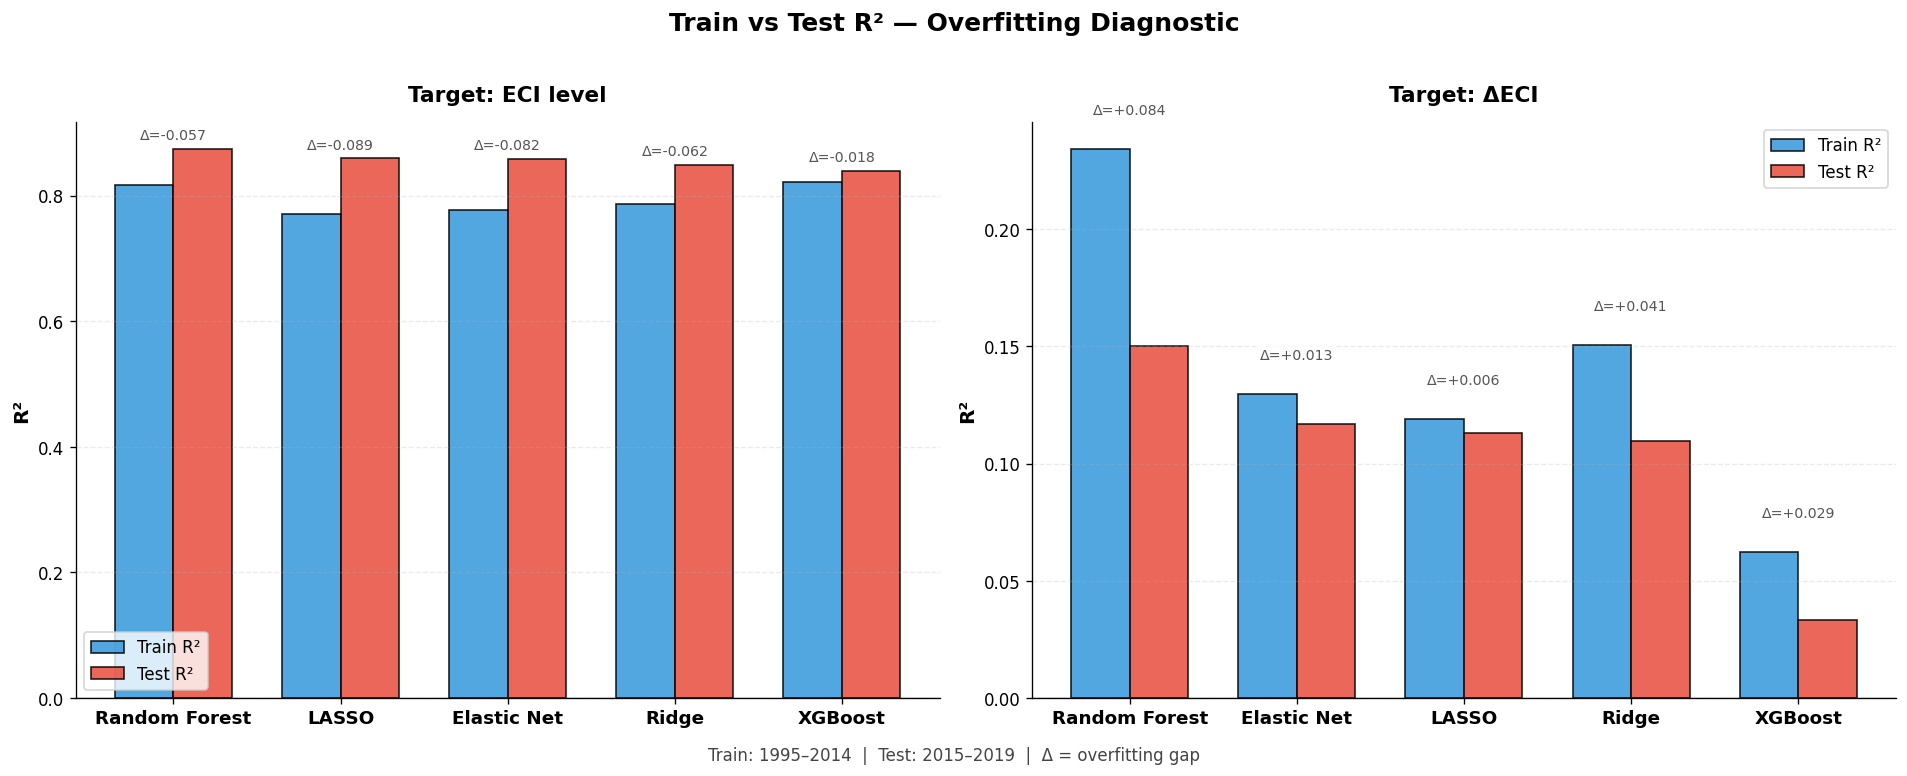

  ✓ Saved OOS_R2_comparison.{png,pdf}
[1b] Train vs Test RMSE comparison...


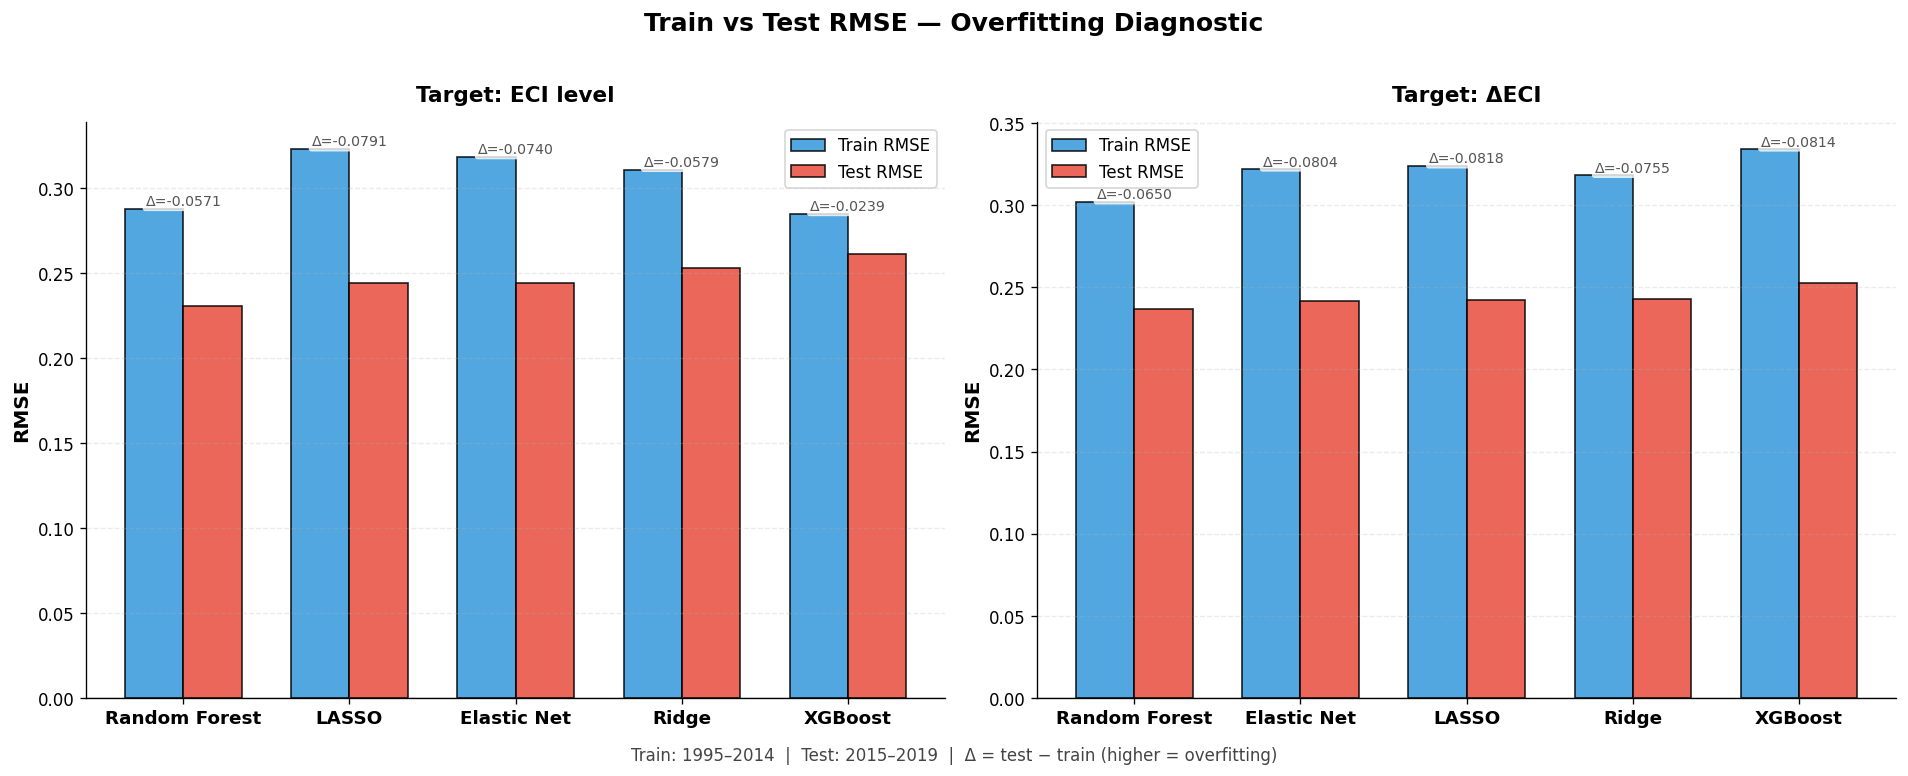

  ✓ Saved OOS_RMSE_comparison.{png,pdf}

[2/4] Predicted vs actual scatter...


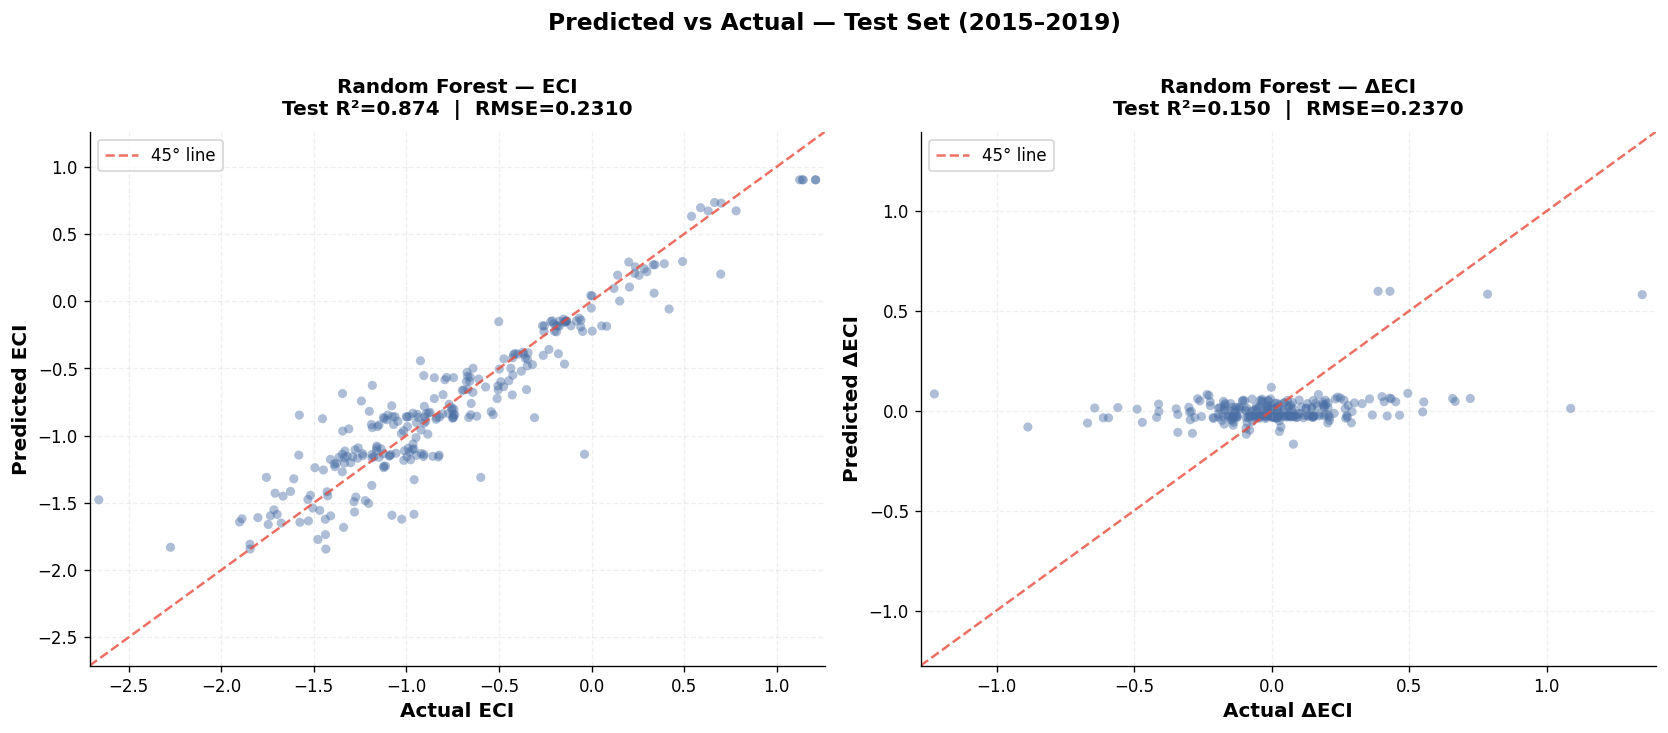

  ✓ Saved PredVsActual_test.{png,pdf}

[3/4] SHAP importance chart...


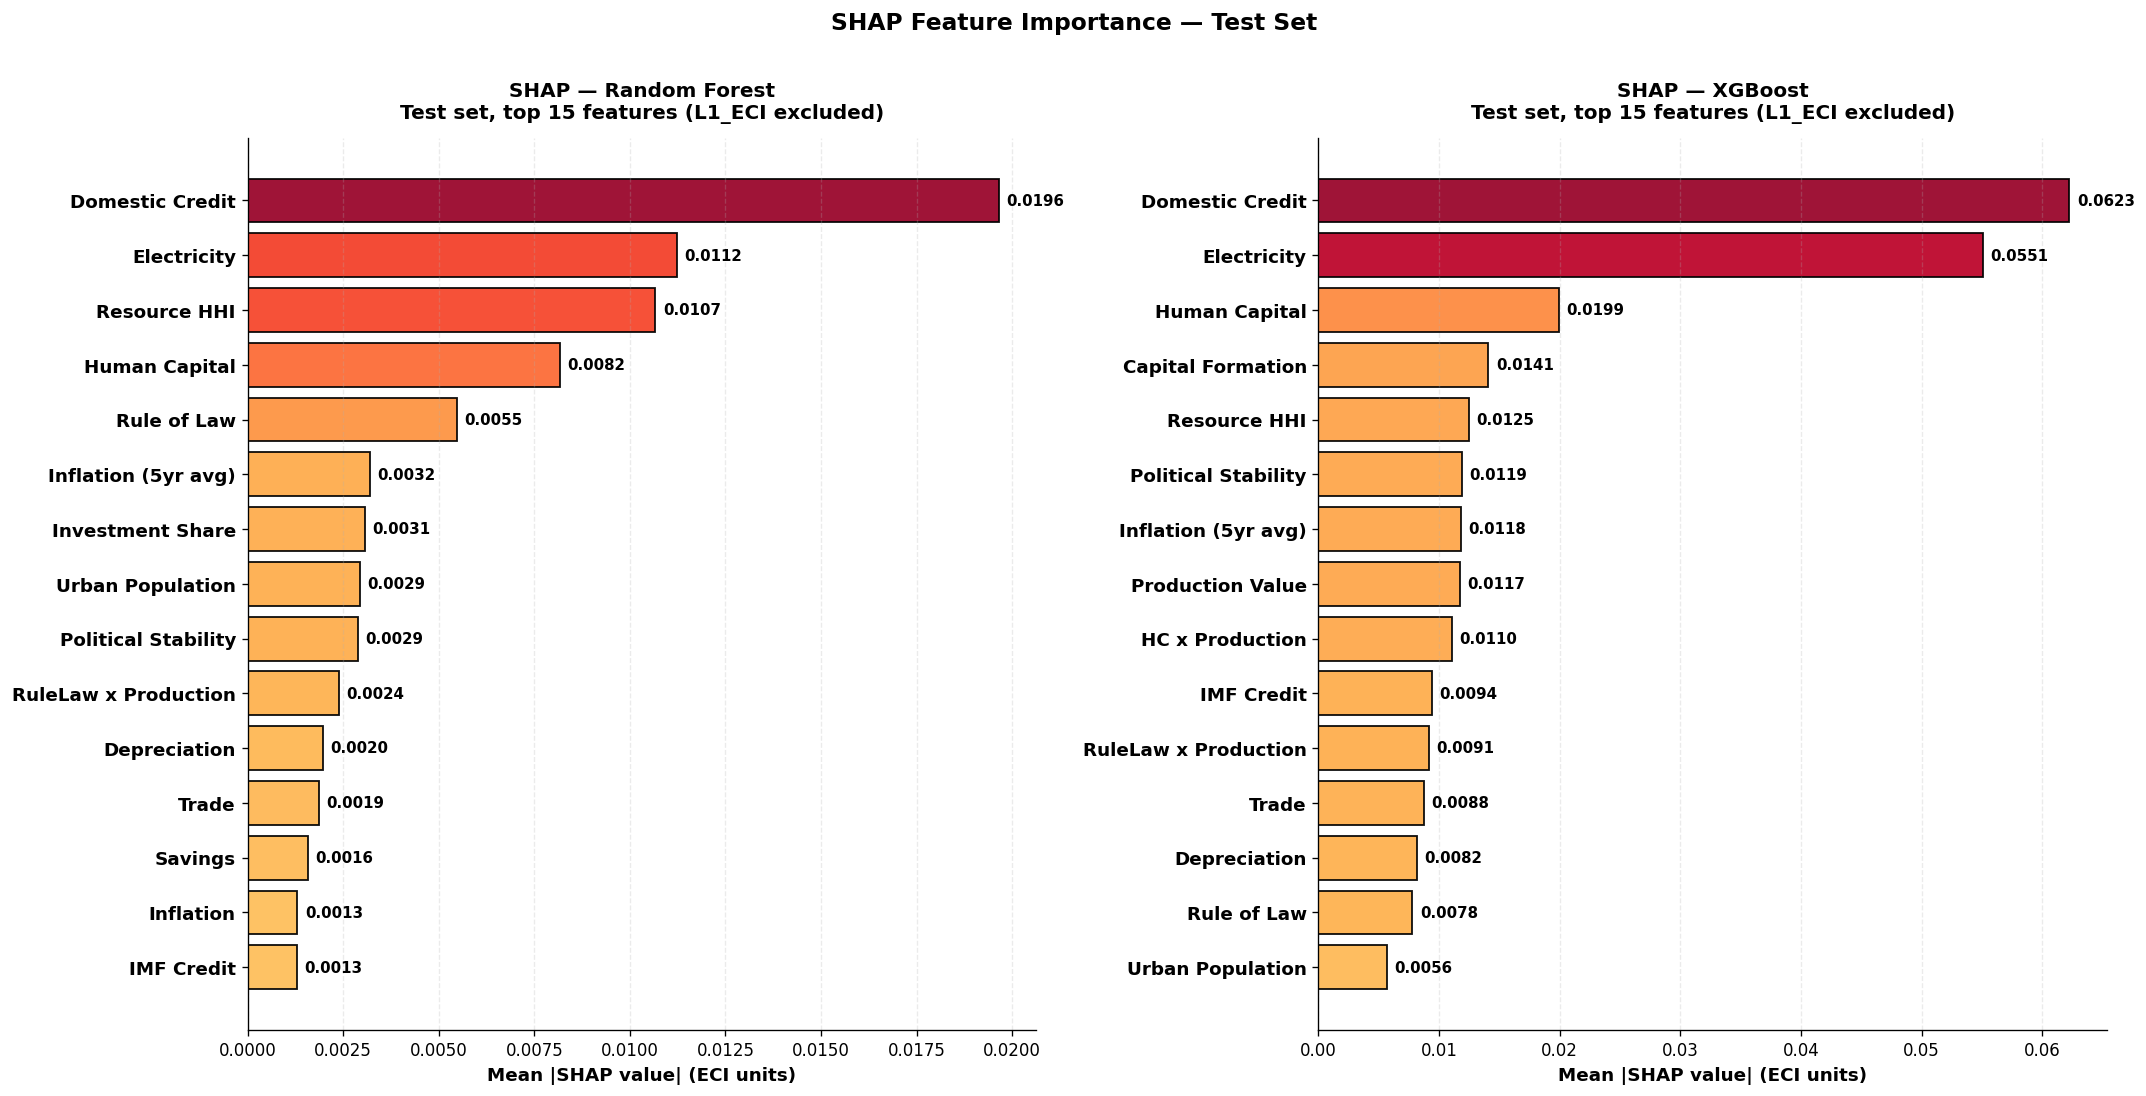

  ✓ Saved SHAP_importance.{png,pdf}

[4/4] Prediction interval chart...


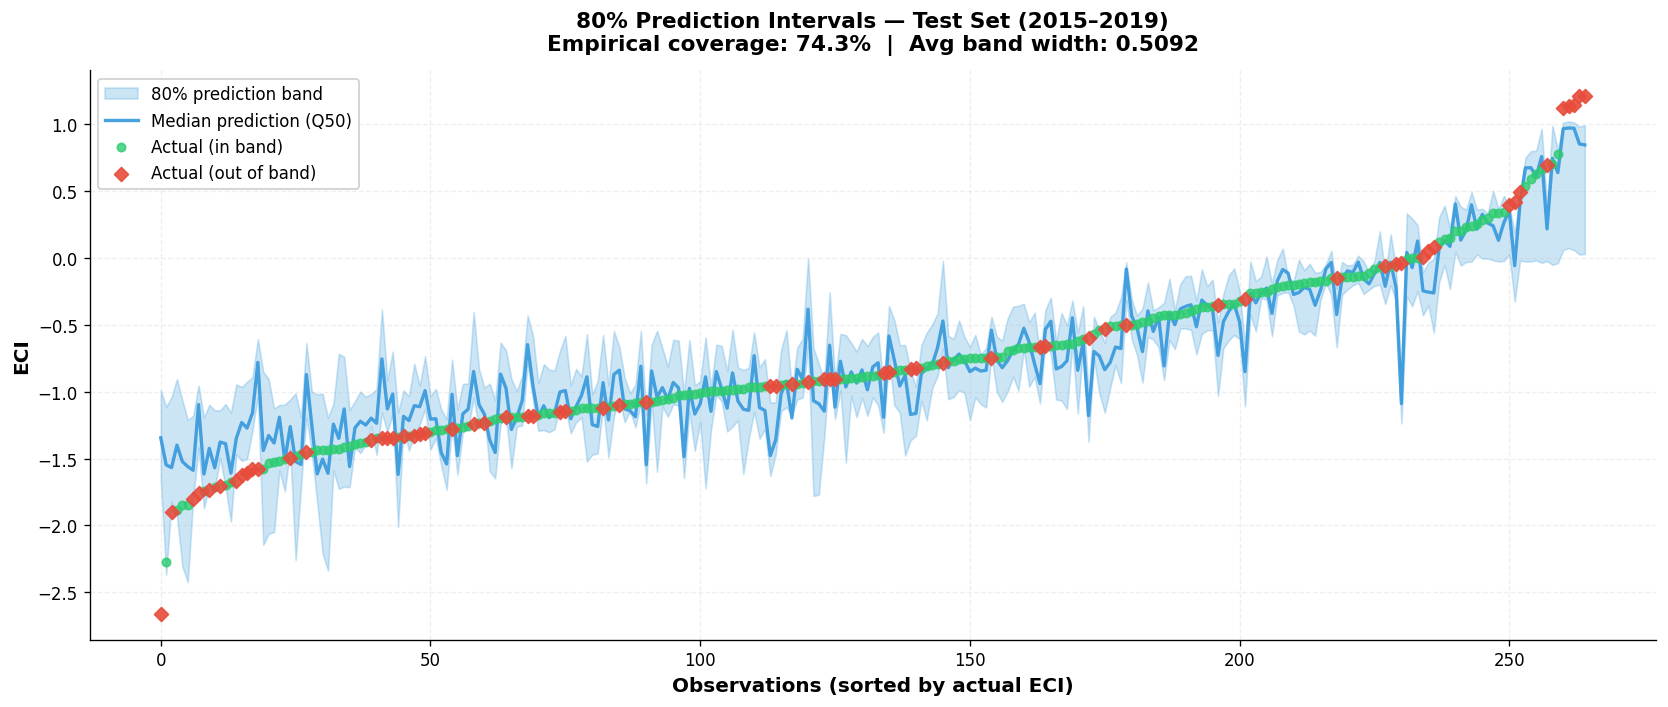

  ✓ Saved PredictionIntervals.{png,pdf}

✓ All static charts saved to Graphics\NB5_TEST/


In [28]:
plt.rcParams.update({
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       120,
})
EXCLUDE = 'L1_ECI'

# ── CHART 1: Train vs Test R² ─────────────────────────────────────────────────
print("[1/4] Train vs Test R² comparison...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, perf, title in zip(axes,
                            [perf_level, perf_delta],
                            ['Target: ECI level', 'Target: ΔECI']):
    model_names = perf['Model'].tolist()
    x = np.arange(len(model_names))
    w = 0.35

    bars_tr = ax.bar(x - w/2, perf['Train R²'], w, label='Train R²',
                     color='#3498DB', alpha=0.85, edgecolor='black', linewidth=1)
    bars_te = ax.bar(x + w/2, perf['Test R²'],  w, label='Test R²',
                     color='#E74C3C', alpha=0.85, edgecolor='black', linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11, fontweight='bold')
    ax.set_ylabel('R²', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)

    # Annotate gap
    for i, (tr, te) in enumerate(zip(perf['Train R²'], perf['Test R²'])):
        gap = tr - te
        ax.text(i, max(tr, te) + 0.015, f'Δ={gap:+.3f}',
                ha='center', fontsize=8.5, color='#555',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

plt.suptitle('Train vs Test R² — Overfitting Diagnostic',
             fontsize=15, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.02, 'Train: 1995–2014  |  Test: 2015–2019  |  Δ = overfitting gap',
            ha='center', fontsize=10, color='#444')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'OOS_R2_comparison.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'OOS_R2_comparison.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved OOS_R2_comparison.{png,pdf}")

# ── CHART 1b: Train vs Test RMSE ──────────────────────────────────────────────
print("[1b] Train vs Test RMSE comparison...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, perf, title in zip(axes,
                            [perf_level, perf_delta],
                            ['Target: ECI level', 'Target: ΔECI']):
    model_names = perf['Model'].tolist()
    x = np.arange(len(model_names))
    w = 0.35

    bars_tr = ax.bar(x - w/2, perf['Train RMSE'], w, label='Train RMSE',
                     color='#3498DB', alpha=0.85, edgecolor='black', linewidth=1)
    bars_te = ax.bar(x + w/2, perf['Test RMSE'],  w, label='Test RMSE',
                     color='#E74C3C', alpha=0.85, edgecolor='black', linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11, fontweight='bold')
    ax.set_ylabel('RMSE', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)

    # Annotate gap
    for i, (tr, te) in enumerate(zip(perf['Train RMSE'], perf['Test RMSE'])):
        gap = te - tr
        ax.text(i, max(tr, te) + 0.002, f'Δ={gap:+.4f}',
                ha='center', fontsize=8.5, color='#555',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

plt.suptitle('Train vs Test RMSE — Overfitting Diagnostic',
             fontsize=15, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.02, 'Train: 1995–2014  |  Test: 2015–2019  |  Δ = test − train (higher = overfitting)',
            ha='center', fontsize=10, color='#444')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'OOS_RMSE_comparison.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'OOS_RMSE_comparison.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved OOS_RMSE_comparison.{png,pdf}")


# ── CHART 2: Predicted vs Actual (test set) ────────────────────────────────────
print("\n[2/4] Predicted vs actual scatter...")

# Best model on test R² for each target
best_level_name = perf_level.iloc[0]['Model']
best_delta_name = perf_delta.iloc[0]['Model']

pred_level_best = models_level[best_level_name].predict(X_test)
pred_delta_best = models_delta[best_delta_name].predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, actual, pred, name, target in zip(
    axes,
    [y_test_level, y_test_delta],
    [pred_level_best, pred_delta_best],
    [best_level_name, best_delta_name],
    ['ECI', 'ΔECI']
):
    r2_val = r2_score(actual, pred)
    rmse_val = np.sqrt(mean_squared_error(actual, pred))

    ax.scatter(actual, pred, alpha=0.45, s=30, color='#4a6fa5', edgecolor='none')

    lims = [min(actual.min(), pred.min()) - 0.05,
            max(actual.max(), pred.max()) + 0.05]
    ax.plot(lims, lims, '--', color='#E74C3C', linewidth=1.5, alpha=0.8, label='45° line')
    ax.set_xlim(lims); ax.set_ylim(lims)

    ax.set_xlabel(f'Actual {target}', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Predicted {target}', fontsize=12, fontweight='bold')
    ax.set_title(f'{name} — {target}\nTest R²={r2_val:.3f}  |  RMSE={rmse_val:.4f}',
                 fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.2, linestyle='--')

plt.suptitle('Predicted vs Actual — Test Set (2015–2019)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'PredVsActual_test.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'PredVsActual_test.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved PredVsActual_test.{png,pdf}")


# ── CHART 3: SHAP bar chart ────────────────────────────────────────────────────
print("\n[3/4] SHAP importance chart...")

if HAS_SHAP and shap_results:
    shap_model_names = list(shap_results.keys())
    n_panels = len(shap_model_names)
    fig, axes = plt.subplots(1, n_panels, figsize=(9 * n_panels, 9))
    if n_panels == 1:
        axes = [axes]

    for ax, model_name in zip(axes, shap_model_names):
        shap_vals = shap_results[model_name]
        mean_abs  = np.abs(shap_vals).mean(axis=0)

        # Exclude L1_ECI from display
        feat_idx = [i for i, f in enumerate(all_features) if f != EXCLUDE]
        mean_abs_plot = mean_abs[feat_idx]
        names_plot    = [short_names[i] for i in feat_idx]

        sort_idx = np.argsort(mean_abs_plot)
        top15    = sort_idx[-15:]

        norm_vals  = mean_abs_plot[top15] / mean_abs_plot[top15].max()
        cmap       = plt.cm.YlOrRd
        bar_colors = [cmap(0.3 + 0.65 * v) for v in norm_vals]

        y_pos = np.arange(len(top15))
        ax.barh(y_pos, mean_abs_plot[top15], color=bar_colors,
                edgecolor='black', linewidth=1.1, alpha=0.92)
        ax.set_yticks(y_pos)
        ax.set_yticklabels([names_plot[i] for i in top15], fontsize=11, fontweight='bold')
        ax.set_xlabel('Mean |SHAP value| (ECI units)', fontsize=11, fontweight='bold')
        ax.set_title(f'SHAP — {model_name}\nTest set, top 15 features (L1_ECI excluded)',
                     fontsize=12, fontweight='bold', pad=12)
        ax.grid(axis='x', alpha=0.25, linestyle='--')

        for i, val in enumerate(mean_abs_plot[top15]):
            ax.text(val + mean_abs_plot[top15].max() * 0.01, i, f'{val:.4f}',
                    va='center', fontsize=9, fontweight='bold')

    plt.suptitle('SHAP Feature Importance — Test Set', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'SHAP_importance.png'), dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(os.path.join(OUT, 'SHAP_importance.pdf'), bbox_inches='tight')
    plt.show()
    print("  ✓ Saved SHAP_importance.{png,pdf}")
else:
    print("  Skipped — SHAP not available")


# ── CHART 4: Prediction intervals ─────────────────────────────────────────────
print("\n[4/4] Prediction interval chart...")

plot_df = interval_df.sort_values('Actual').reset_index(drop=True)
x_idx = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(x_idx, plot_df['Q10'], plot_df['Q90'],
                alpha=0.25, color='#3498DB', label='80% prediction band')
ax.plot(x_idx, plot_df['Q50'], color='#3498DB', linewidth=2,
        label='Median prediction (Q50)', alpha=0.9)
ax.scatter(x_idx[plot_df['In_Band']],  plot_df.loc[plot_df['In_Band'],  'Actual'],
           color='#2ECC71', s=25, alpha=0.8, zorder=3, label='Actual (in band)')
ax.scatter(x_idx[~plot_df['In_Band']], plot_df.loc[~plot_df['In_Band'], 'Actual'],
           color='#E74C3C', s=35, alpha=0.9, zorder=4, label='Actual (out of band)', marker='D')

ax.set_xlabel('Observations (sorted by actual ECI)', fontsize=12, fontweight='bold')
ax.set_ylabel('ECI', fontsize=12, fontweight='bold')
ax.set_title(
    f'80% Prediction Intervals — Test Set (2015–2019)\n'
    f'Empirical coverage: {coverage:.1%}  |  Avg band width: {avg_width:.4f}',
    fontsize=13, fontweight='bold', pad=12
)
ax.legend(fontsize=10, loc='upper left', framealpha=0.95)
ax.grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'PredictionIntervals.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'PredictionIntervals.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved PredictionIntervals.{png,pdf}")

print(f"\n✓ All static charts saved to {OUT}/")

## 8. Visualisations — Interactive (Plotly)

Interactive versions of the OOS comparison and prediction interval charts, using the standard portfolio style.

In [29]:
STYLE = {
    'font_family': 'IBM Plex Sans, -apple-system, BlinkMacSystemFont, sans-serif',
    'tick_size': 11,
    'axis_title_size': 13,
    'legend_size': 11,
    'annotation_size': 10,
    'title_color': '#1a2744',
    'template': 'plotly_white',
    'plot_bg': '#fafafa',
    'paper_bg': '#fafafa',
    'chart_height': 550,
    'chart_height_tall': 650,
    'margin': dict(l=60, r=40, t=60, b=60),
    'margin_bar': dict(l=160, r=130, t=60, b=60),
    'grid_color': '#e5e7eb',
    'grid_width': 0.5,
}
WRITE_CONFIG = {'displayModeBar': False, 'responsive': True}
PALETTE = {
    'blue': '#4a6fa5', 'red': '#c23a3a', 'green': '#2e7d4a',
    'orange': '#d4853b', 'light_blue': '#7a9dc4', 'grey': '#999999',
}

def base_layout(**kwargs):
    layout = dict(
        template=STYLE['template'],
        plot_bgcolor=STYLE['plot_bg'],
        paper_bgcolor=STYLE['paper_bg'],
        font=dict(family=STYLE['font_family'], size=STYLE['tick_size'],
                  color=STYLE['title_color']),
        margin=STYLE['margin'],
        height=STYLE['chart_height'],
    )
    layout.update(kwargs)
    return layout

def save_chart(fig, path_no_ext, width=1100, height=600):
    fig.show()
    fig.write_html(f"{path_no_ext}.html", config=WRITE_CONFIG)
    print(f"  ✓ {path_no_ext}.html")
    for engine in ['kaleido', 'orca']:
        try:
            fig.write_image(f"{path_no_ext}.png", width=width, height=height, scale=3, engine=engine)
            print(f"  ✓ {path_no_ext}.png ({engine})")
            return
        except Exception:
            pass
    print("  ⚠ PNG skipped.")


# ── CHART A: Train vs Test R² (grouped bar) ───────────────────────────────────
print("[A] OOS R² comparison...")

figA = make_subplots(rows=1, cols=2,
                     subplot_titles=['Target: ECI level', 'Target: ΔECI'],
                     horizontal_spacing=0.1)

for col, perf in enumerate([perf_level, perf_delta], 1):
    figA.add_trace(go.Bar(
        name='Train R²', x=perf['Model'], y=perf['Train R²'],
        marker_color=PALETTE['blue'], opacity=0.85,
        text=[f'{v:.3f}' for v in perf['Train R²']], textposition='outside',
        showlegend=(col == 1),
    ), row=1, col=col)
    figA.add_trace(go.Bar(
        name='Test R²', x=perf['Model'], y=perf['Test R²'],
        marker_color=PALETTE['red'], opacity=0.85,
        text=[f'{v:.3f}' for v in perf['Test R²']], textposition='outside',
        showlegend=(col == 1),
    ), row=1, col=col)
    figA.update_yaxes(title_text='R²' if col == 1 else '',
                      gridcolor=STYLE['grid_color'], row=1, col=col)

figA.update_layout(**base_layout(
    barmode='group',
    height=STYLE['chart_height'],
    legend=dict(orientation='h', y=-0.15, x=0.5, xanchor='center',
                font=dict(size=STYLE['legend_size'])),
    margin=dict(l=60, r=40, t=80, b=80),
))
save_chart(figA, os.path.join(OUT, 'OOS_R2_interactive'))


# ── CHART B: Prediction intervals ─────────────────────────────────────────────
print("\n[B] Prediction intervals...")

plot_df_sort = interval_df.sort_values('Actual').reset_index(drop=True)
x_labels = plot_df_sort.apply(lambda r: f"{r['Country Code']} {int(r['Year'])}", axis=1)

figB = go.Figure()

figB.add_trace(go.Scatter(
    x=list(range(len(plot_df_sort))),
    y=plot_df_sort['Q90'].tolist() + plot_df_sort['Q10'].tolist()[::-1],
    fill='toself',
    fillcolor='rgba(74, 111, 165, 0.2)',
    line=dict(color='rgba(0,0,0,0)'),
    hoverinfo='skip',
    name='80% prediction band',
    showlegend=True,
))
figB.add_trace(go.Scatter(
    x=list(range(len(plot_df_sort))),
    y=plot_df_sort['Q50'],
    mode='lines',
    line=dict(color=PALETTE['blue'], width=2),
    name='Median (Q50)',
))
in_band_mask  = plot_df_sort['In_Band']
out_band_mask = ~in_band_mask

figB.add_trace(go.Scatter(
    x=plot_df_sort.index[in_band_mask].tolist(),
    y=plot_df_sort.loc[in_band_mask, 'Actual'],
    mode='markers',
    marker=dict(color=PALETTE['green'], size=7, opacity=0.85),
    name='Actual (in band)',
    hovertemplate='%{text}<br>Actual: %{y:.3f}<extra></extra>',
    text=x_labels[in_band_mask].tolist(),
))
figB.add_trace(go.Scatter(
    x=plot_df_sort.index[out_band_mask].tolist(),
    y=plot_df_sort.loc[out_band_mask, 'Actual'],
    mode='markers',
    marker=dict(color=PALETTE['red'], size=9, symbol='diamond', opacity=0.9),
    name='Actual (out of band)',
    hovertemplate='%{text}<br>Actual: %{y:.3f}<extra></extra>',
    text=x_labels[out_band_mask].tolist(),
))

figB.update_layout(**base_layout(
    height=STYLE['chart_height'],
    xaxis=dict(title='Observations (sorted by actual)', showticklabels=False,
               gridcolor=STYLE['grid_color']),
    yaxis=dict(title='ECI', gridcolor=STYLE['grid_color']),
    annotations=[dict(
        text=f"Coverage: {coverage:.1%}  |  Avg width: {avg_width:.4f}",
        xref='paper', yref='paper', x=0.01, y=0.99,
        showarrow=False, font=dict(size=11, color='#555'),
        bgcolor='rgba(250,250,250,0.9)', bordercolor='#ddd', borderwidth=1, borderpad=6,
    )],
    legend=dict(font=dict(size=STYLE['legend_size']),
                bgcolor='rgba(250,250,250,0.9)', bordercolor='#e5e7eb', borderwidth=1),
))
save_chart(figB, os.path.join(OUT, 'PredictionIntervals_interactive'))

print(f"\n✓ All interactive charts saved to {OUT}/")

[A] OOS R² comparison...


  ✓ Graphics\NB5_TEST\OOS_R2_interactive.html
  ✓ Graphics\NB5_TEST\OOS_R2_interactive.png (kaleido)

[B] Prediction intervals...


  ✓ Graphics\NB5_TEST\PredictionIntervals_interactive.html
  ✓ Graphics\NB5_TEST\PredictionIntervals_interactive.png (kaleido)

✓ All interactive charts saved to Graphics\NB5_TEST/


## Summary

| Improvement | Implementation |
|---|---|
| Temporal hold-out | Train 1995–2014 / Test 2015–2019 |
| Honest target | ΔECI (year-on-year change) alongside log(ECI) |
| New features | Inflation 5yr avg, Real rate 5yr avg, Resource HHI |
| New model | XGBoost with early stopping |
| Importance | SHAP (tree explainer, test set) |
| Uncertainty | Quantile GB at Q10/Q50/Q90 → 80% bands |
| Not changed | Feature list, log transforms, sample, NB4 compatibility |

In [30]:
# ── NB5_TEST SUMMARY ──────────────────────────────────────────────────────────
print("=" * 65)
print("  NB5_TEST SUMMARY — Improved ML Methods")
print("=" * 65)
print(f"  Sample       : {df['Country Code'].nunique()} countries × {df['Year'].nunique()} years = {len(df)} obs")
print(f"  Train / Test : {len(train_df)} obs (1995–{TRAIN_END}) / {len(test_df)} obs ({TEST_START}–2019)")
print(f"  Features     : {len(all_features)} (base + 3 new: roll5 inflation, roll5 real rate, HHI)")
print()
print("  OOS performance — ECI level:")
for _, row in perf_level.iterrows():
    print(f"    {row['Model']:<14}  Train R²={row['Train R²']:.4f}  Test R²={row['Test R²']:.4f}  "
          f"Gap={row['Overfit Gap']:+.4f}  TestRMSE={row['Test RMSE']:.4f}")
print()
print("  OOS performance — ΔECI:")
for _, row in perf_delta.iterrows():
    print(f"    {row['Model']:<14}  Train R²={row['Train R²']:.4f}  Test R²={row['Test R²']:.4f}  "
          f"Gap={row['Overfit Gap']:+.4f}  TestRMSE={row['Test RMSE']:.4f}")
print()
print(f"  Prediction intervals (80%):")
print(f"    Empirical coverage : {coverage:.1%}")
print(f"    Avg band width     : {avg_width:.4f} (ECI units)")
if HAS_SHAP and shap_results:
    print()
    for model_name, shap_vals in shap_results.items():
        mean_abs = np.abs(shap_vals).mean(axis=0)
        feat_idx = [i for i, f in enumerate(all_features) if f != EXCLUDE]
        top3 = np.argsort(mean_abs[feat_idx])[::-1][:3]
        names_top3 = [short_names[feat_idx[i]] for i in top3]
        print(f"  SHAP top 3 ({model_name}): {names_top3}")
print()
print(f"  Graphics saved to: {OUT}/")
print("=" * 65)

  NB5_TEST SUMMARY — Improved ML Methods
  Sample       : 53 countries × 23 years = 1199 obs
  Train / Test : 934 obs (1995–2014) / 265 obs (2015–2019)
  Features     : 23 (base + 3 new: roll5 inflation, roll5 real rate, HHI)

  OOS performance — ECI level:
    Random Forest   Train R²=0.8174  Test R²=0.8743  Gap=-0.0568  TestRMSE=0.2310
    LASSO           Train R²=0.7702  Test R²=0.8596  Gap=-0.0894  TestRMSE=0.2441
    Elastic Net     Train R²=0.7767  Test R²=0.8590  Gap=-0.0823  TestRMSE=0.2446
    Ridge           Train R²=0.7871  Test R²=0.8490  Gap=-0.0619  TestRMSE=0.2532
    XGBoost         Train R²=0.8212  Test R²=0.8393  Gap=-0.0181  TestRMSE=0.2612

  OOS performance — ΔECI:
    Random Forest   Train R²=0.2342  Test R²=0.1501  Gap=+0.0841  TestRMSE=0.2370
    Elastic Net     Train R²=0.1296  Test R²=0.1167  Gap=+0.0129  TestRMSE=0.2416
    LASSO           Train R²=0.1189  Test R²=0.1130  Gap=+0.0059  TestRMSE=0.2421
    Ridge           Train R²=0.1506  Test R²=0.1096  Gap=+0